##### 실행 환경 설정

In [1]:
# Google Drive를 Colab에 마운트
from google.colab import drive
drive.mount("/google_drive")

from pathlib import Path
import shutil
import zipfile
import yaml

# 작업 경로 설정
WORK_DIR = Path("/google_drive/Othercomputers/내 Mac/sec08")
if not WORK_DIR.exists():
    raise FileNotFoundError(f"작업 폴더를 찾을 수 없습니다: {WORK_DIR}")

print("\n[작업 폴더 목록]")
%cd {WORK_DIR}
!ls

# Google Drive의 ZIP을 Colab 로컬로 복사하고 압축 해제
DRIVE_DATASET_ZIP = WORK_DIR / "datasets" / "lane-seg.zip"
LOCAL_DATASET_ZIP = Path("/datasets/lane-seg.zip")
DATASET_PATH = Path("/datasets/lane-seg")

if not DRIVE_DATASET_ZIP.exists():
    raise FileNotFoundError(f"Drive에서 데이터셋 ZIP을 찾을 수 없습니다: {DRIVE_DATASET_ZIP}")

DATASET_READY = all(
    (DATASET_PATH / relative_path).exists()
    for relative_path in [
        "data.yaml", "images/train", "labels/train",
        "images/val", "labels/val", "images/test", "labels/test",
    ]
)

if not DATASET_READY:
    DATASET_PATH.mkdir(parents=True, exist_ok=True)
    LOCAL_DATASET_ZIP.parent.mkdir(parents=True, exist_ok=True)
    print("\nlane-seg.zip을 Colab 로컬로 복사 중...")
    shutil.copy2(DRIVE_DATASET_ZIP, LOCAL_DATASET_ZIP)

    print("lane-seg 데이터셋 압축 해제 중...")
    with zipfile.ZipFile(LOCAL_DATASET_ZIP, "r") as zip_file:
        zip_file.extractall(DATASET_PATH)

    LOCAL_DATASET_ZIP.unlink(missing_ok=True)

print("\n[데이터셋 폴더 목록]")
print(DATASET_PATH)
!ls {DATASET_PATH}
!ls {DATASET_PATH}/images
!ls {DATASET_PATH}/labels

# data.yaml의 path를 Colab 절대 경로로 변경
yaml_path = DATASET_PATH / "data.yaml"
with open(yaml_path, "r", encoding="utf-8") as file:
    cfg = yaml.safe_load(file)

cfg["path"] = str(DATASET_PATH)

with open(yaml_path, "w", encoding="utf-8") as file:
    yaml.safe_dump(cfg, file, allow_unicode=True, sort_keys=False)

print("\n[data.yaml]")
print(cfg)

# 한글 폰트 설치
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
!apt-get -qq install fonts-nanum
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

Mounted at /google_drive

[작업 폴더 목록]
/google_drive/Othercomputers/내 Mac/sec08
01_object_detection_yolo_info.ipynb	      datasets
02_object_detection_yolo_dataset.ipynb	      detect
03_object_detection_yolo_train.ipynb	      runs
04_object_detection_yolo_visualization.ipynb  yolo11n.pt
05_segmentation_yolo_info.ipynb		      yolo11n-seg.pt
06_segmentation_yolo_train.ipynb	      yolo26n.pt
07_segmentation_yolo_visualization.ipynb      yolo26n-seg.pt

lane-seg.zip을 Colab 로컬로 복사 중...
lane-seg 데이터셋 압축 해제 중...

[데이터셋 폴더 목록]
/datasets/lane-seg
data.yaml  images  labels
test  train  val
test  train  val

[data.yaml]
{'path': '/datasets/lane-seg', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'center_lane', 1: 'left_lane', 2: 'right_lane'}}
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...

##### 임포트

In [2]:
%pip install -q -U ultralytics

from ultralytics import YOLO
import torch
from pathlib import Path
from IPython.display import Image, display

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


##### Device 설정

In [3]:
# 200 epoch가 CPU에서 실행되지 않도록 Colab GPU 사용 여부 확인
if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU를 사용할 수 없습니다. Colab에서 런타임 > 런타임 유형 변경 > T4 GPU를 선택하세요."
    )

DEVICE = 0
print("사용 디바이스: cuda:0")
print("GPU 이름:", torch.cuda.get_device_name(0))

사용 디바이스: cuda:0
GPU 이름: Tesla T4


##### 모델 로드

In [4]:
# 사전 학습된 YOLO 세그멘테이션 모델 로드 (없으면 자동 다운로드)
model = YOLO("yolo26n-seg.pt")

# 모델 구조 요약
model.info()
# Ultralytics 버전에 따라 레이어·파라미터·GFLOPs 수치는 달라질 수 있음
#   - layers    : 모델을 구성하는 총 레이어 수
#   - parameters: 학습 가능한 가중치의 총 개수
#   - gradients : 현재 역전파에 사용 중인 그래디언트 수 (추론 모드에서는 0)
#   - GFLOPs    : 이미지 1장 추론 시 필요한 연산량
# 반환값: (layers, parameters, gradients, GFLOPs) 튜플


YOLO26n-seg summary: 309 layers, 3,126,280 parameters, 0 gradients, 10.5 GFLOPs


(309, 3126280, 0, 10.509952)

##### 파인튜닝하기

In [5]:
# 학습 결과를 Google Drive에 저장
PROJECT_DIR = Path(WORK_DIR) / "runs" / "segment"

train_results = model.train(
    data=str(DATASET_PATH / "data.yaml"),  # data.yaml 경로
    epochs=200,                              # 훈련 에포크 수
    imgsz=320,                               # 입력 이미지 크기
    batch=-1,                                # GPU VRAM의 약 60% 기준 자동 계산
    lr0=0.001,                               # 초기 학습률
    device=DEVICE,                           # Colab T4: cuda:0
    workers=2,                               # Colab 권장 워커 수
    project=str(PROJECT_DIR),                # 결과 상위 폴더
    name="06",                               # 실행 결과 폴더 이름
    exist_ok=True,                           # 동일 폴더 재사용
)

RUN_DIR = Path(model.trainer.save_dir)
print("훈련 결과 저장 위치:", RUN_DIR)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/datasets/lane-seg/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=06, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

학습 결과 확인

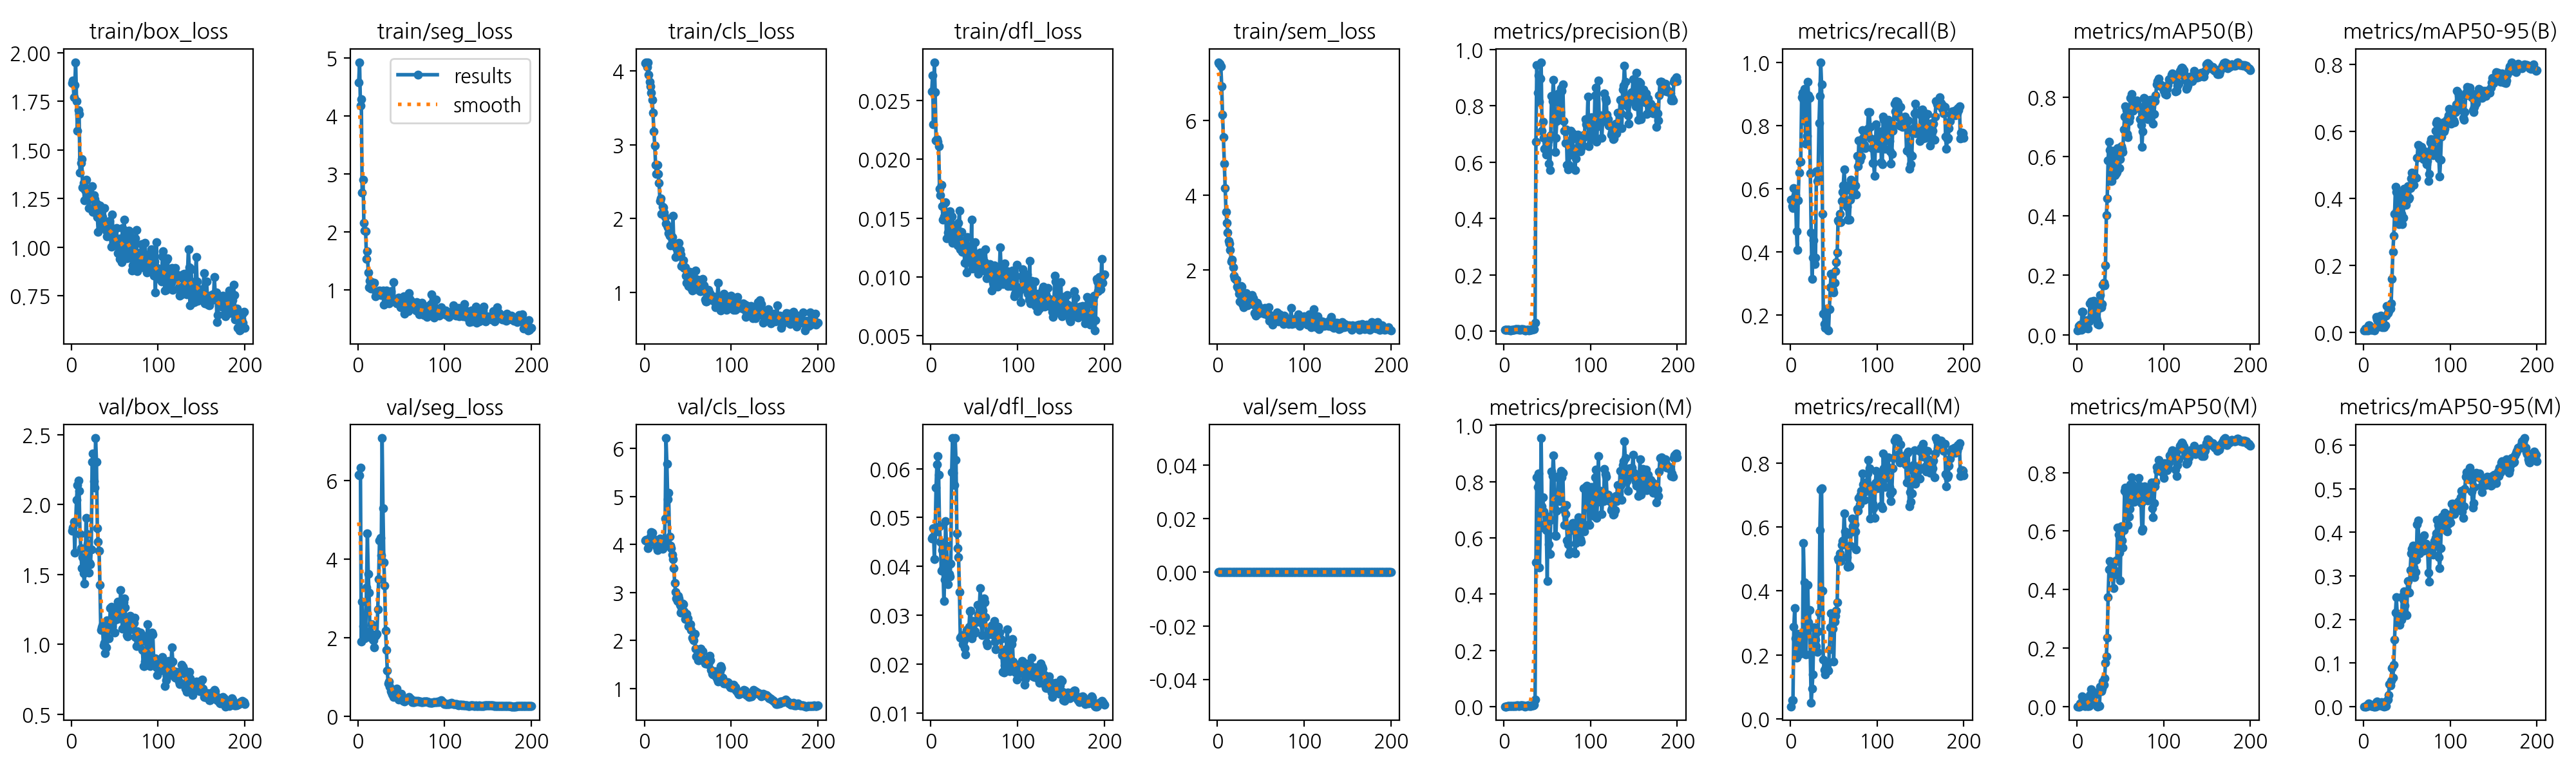

In [6]:
# 훈련/검증 손실 및 mAP 그래프
results_png_path = RUN_DIR / "results.png"
display(Image(filename=str(results_png_path)))

혼동 행렬  
- 정답, 오답, 못찾음(background)의 비율

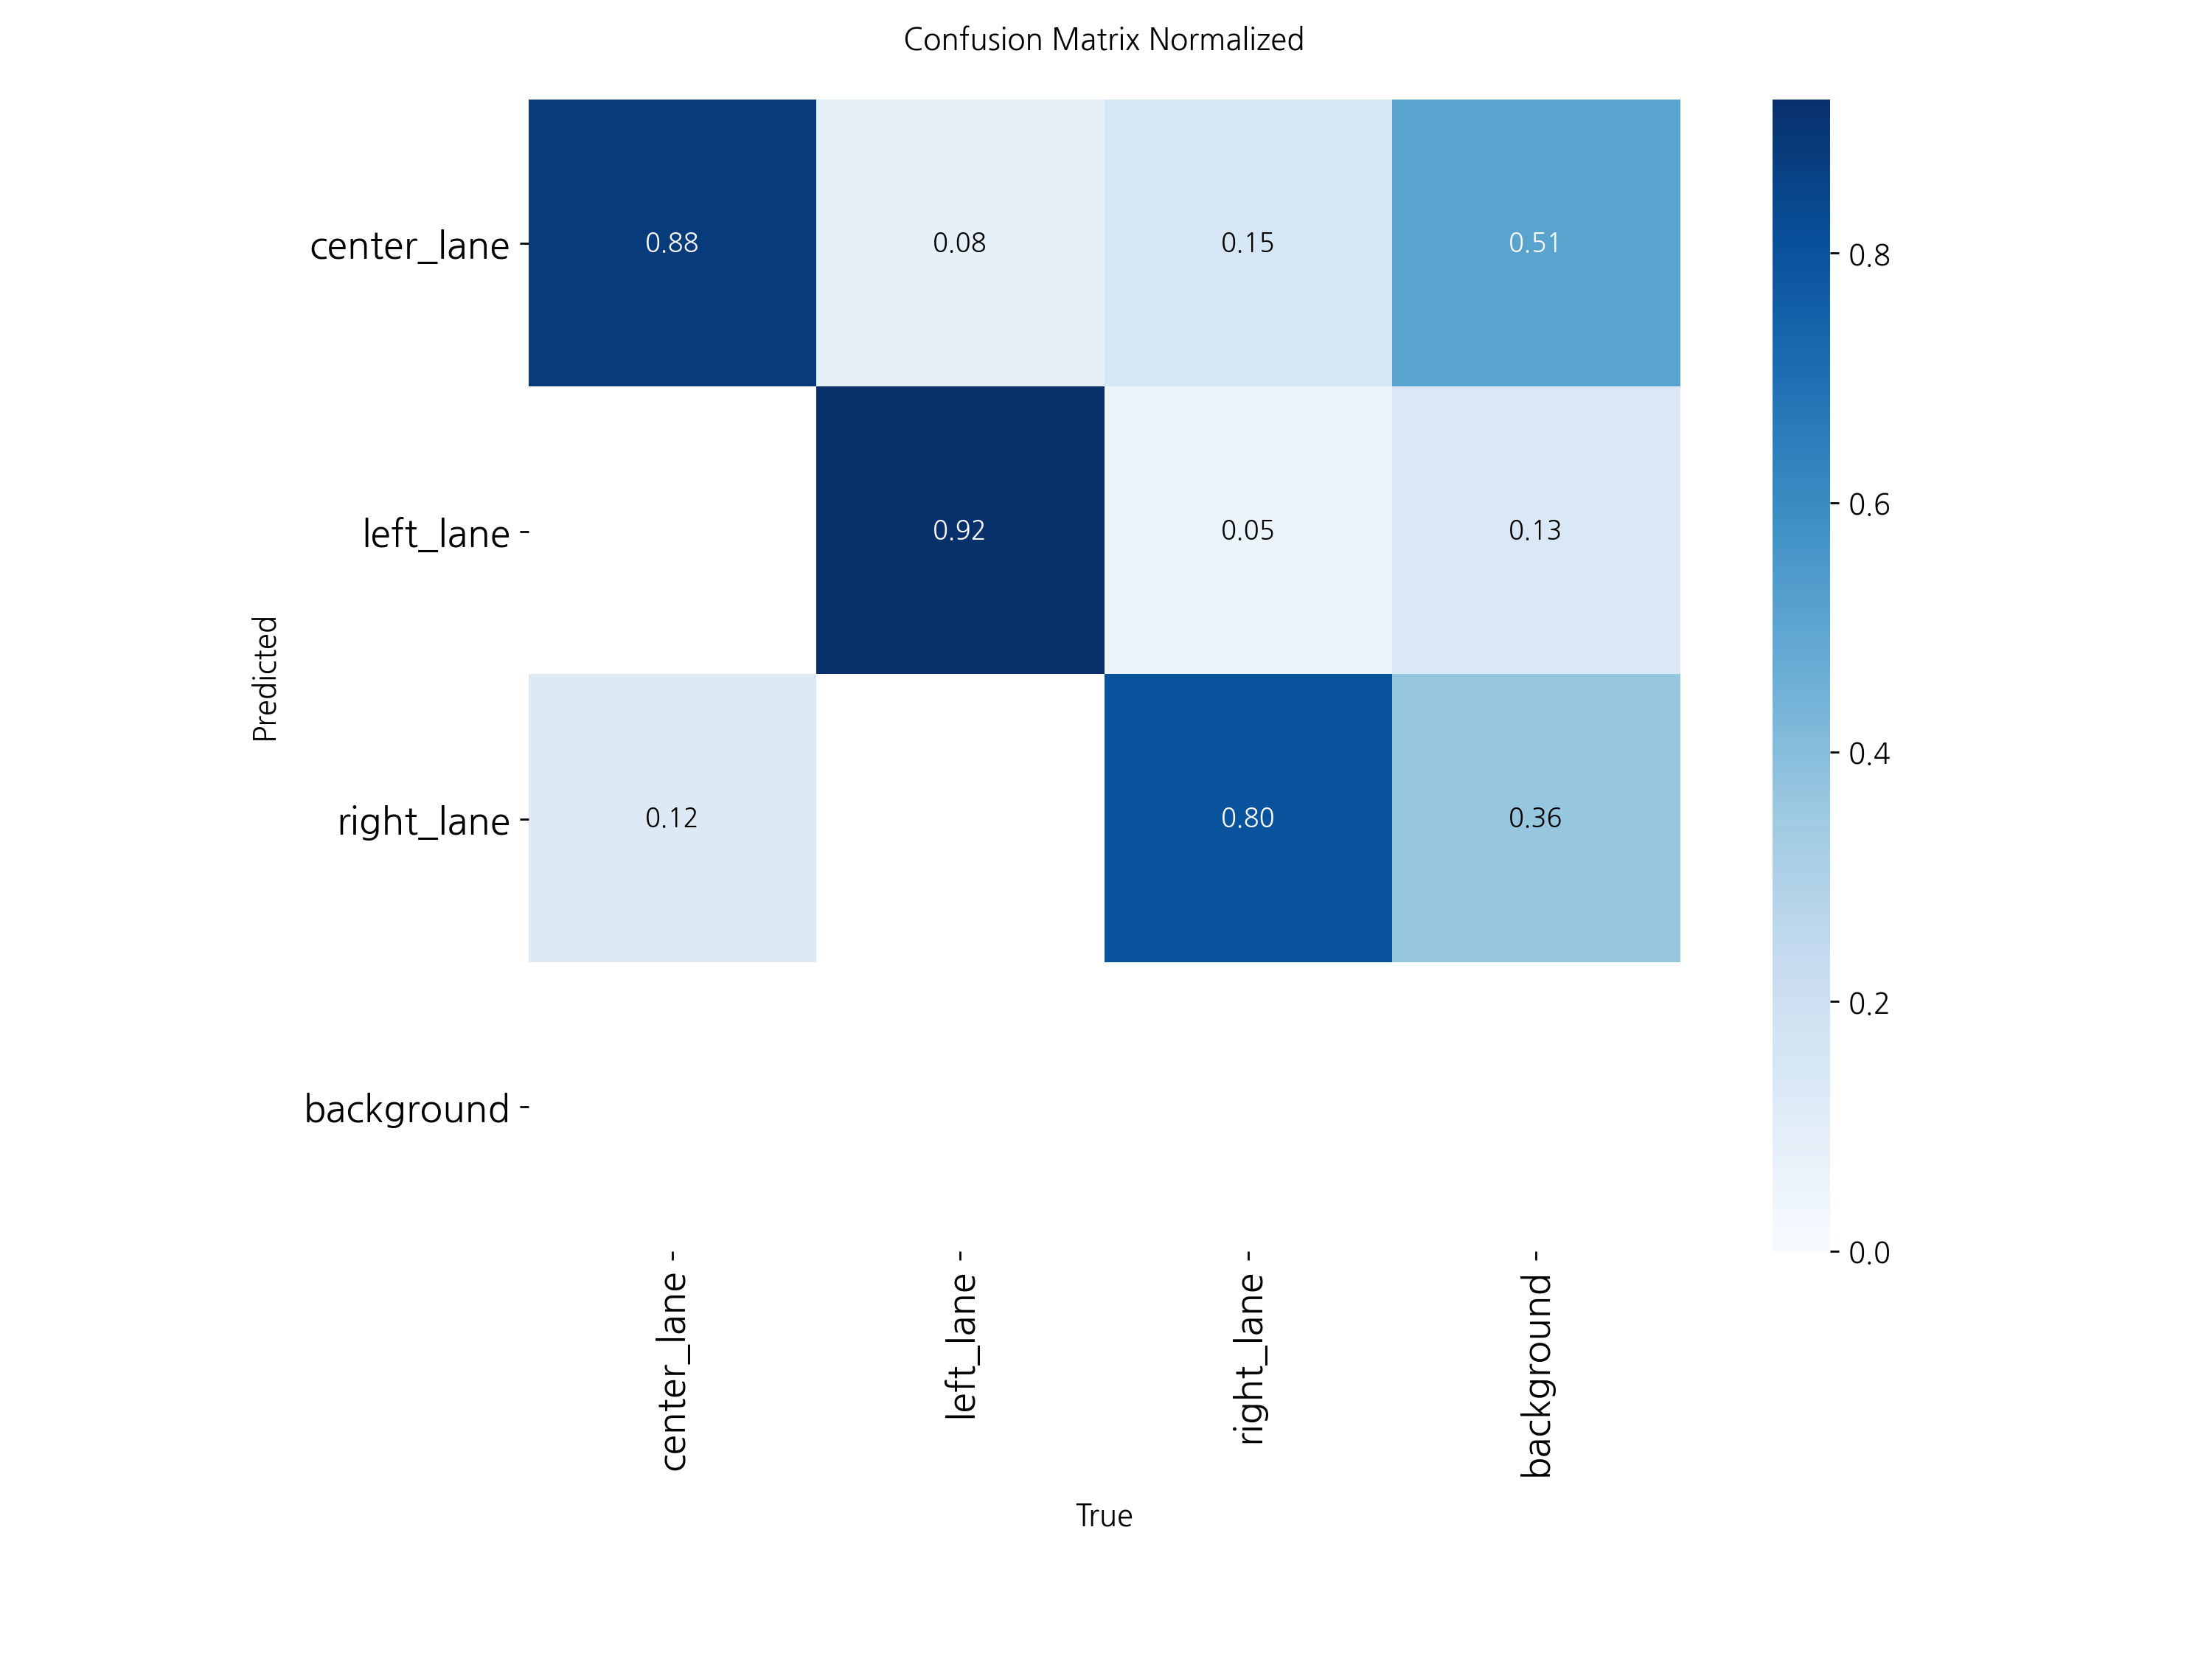

In [7]:
# Confusion Matrix 확인
confusion_matrix_png_path = RUN_DIR / "confusion_matrix_normalized.png"
display(Image(filename=str(confusion_matrix_png_path)))

모델 평가

In [8]:
# 최적 가중치(best.pt) 로드
best_model_path = RUN_DIR / "weights" / "best.pt"
best_model = YOLO(str(best_model_path))

# 테스트 데이터로 최종 평가
test_results = best_model.val(
    data=str(DATASET_PATH / "data.yaml"),
    split="test",
    device=DEVICE,
    project=str(RUN_DIR),
    name="test",
    exist_ok=True,
    verbose=False,
)

print(f"\n[박스]")
print(f"mAP50    : {test_results.box.map50:.4f}")
print(f"mAP50-95 : {test_results.box.map:.4f}")
print(f"Precision: {test_results.box.mp:.4f}")
print(f"Recall   : {test_results.box.mr:.4f}")

print(f"\n[마스크]")
print(f"mAP50    : {test_results.seg.map50:.4f}")
print(f"mAP50-95 : {test_results.seg.map:.4f}")
print(f"Precision: {test_results.seg.mp:.4f}")
print(f"Recall   : {test_results.seg.mr:.4f}")

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,469 parameters, 0 gradients, 9.0 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 20.9±3.8 MB/s, size: 17.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /datasets/lane-seg/labels/test... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 381.8it/s 0.0s
val: New cache created: /datasets/lane-seg/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.5it/s 0.2s
                   all         10         32      0.954      0.776      0.882      0.674      0.954      0.776      0.885      0.561
Speed: 0.1ms preprocess, 10.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /googl